In [379]:
import torch
import torch.nn as nn
import glob
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

## Prepare data

In [2]:
# Read in sample data
ifs_fc_dir = '/glade/derecho/scratch/dcalhoun/ecmwf_ifs/fc/t2m/00/6/2016/01'
ifs_fc_files = sorted(glob.glob(f'{ifs_fc_dir}/*.nc'))
ds_fc = xr.open_mfdataset(ifs_fc_files)
ds_an = xr.open_dataset('/glade/derecho/scratch/dcalhoun/ecmwf_ifs/sample_ifs_analysis.nc').sel(time=ds_fc['t2m'].time.values)
da_error = ds_fc['t2m'] - ds_an['t2m']
da_error = da_error.assign_coords(time=pd.to_datetime(da_error.time).dayofyear) # reassign time coord to day of year

In [328]:
def da_to_samples(da):
    '''
    Given a data array, generate a list of sample vectors
    '''
    samples = np.stack([
                    da.stack(newdim=['latitude','longitude','time']).values,
                    da.stack(newdim=['latitude','longitude','time']).latitude.values,
                    da.stack(newdim=['latitude','longitude','time']).longitude.values,
                    da.stack(newdim=['latitude','longitude','time']).time.values
                ], axis=1)
    return samples

In [343]:
da_error_rec = samples_to_da(np.stack([fc_error_samples_rec, lat_samples, lon_samples, time_samples], axis=1), da_error.shape)

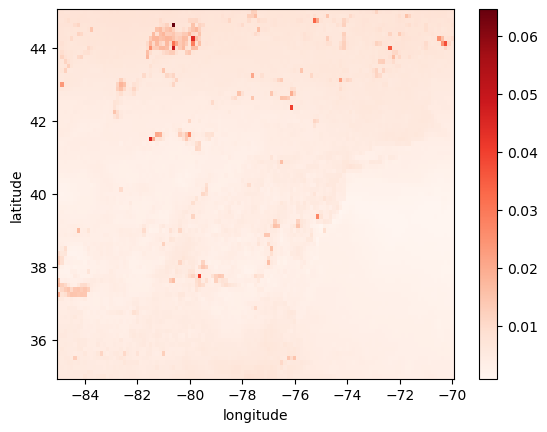

In [359]:
np.sqrt(((da_error_rec - da_error)**2).mean(axis=0)/31).plot(cmap='Reds')

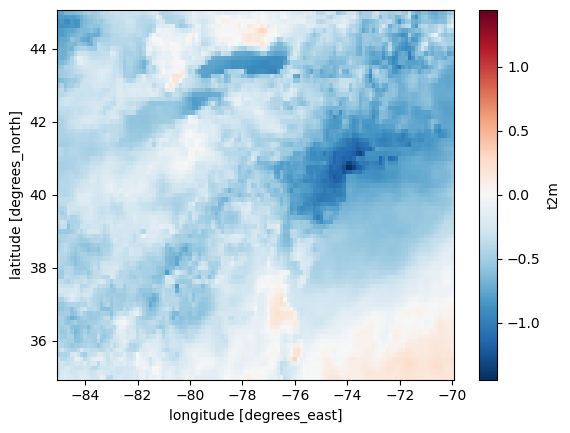

In [346]:
da_error.mean(axis=0).plot()

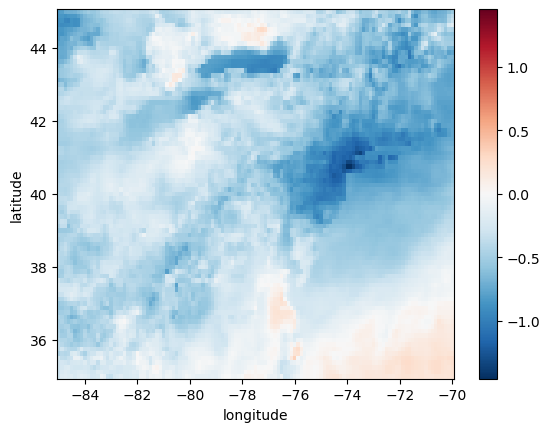

In [347]:
da_error_rec.mean(axis=0).plot()

In [363]:
fc_error_samples_rec

array([-1.4046912 , -0.65522146, -1.199678  , ...,  0.3453099 ,
        0.17066123,  0.10922568], dtype=float32)

In [362]:
samples_index[:,0]

array([-0.71919966, -0.4654143 , -0.6576965 , ..., -0.0364331 ,
       -0.10307193, -0.12862587], dtype=float32)

In [364]:
da_error_index = samples_to_da(np.stack([samples_index[:,0], lat_samples, lon_samples, time_samples], axis=1), da_error.shape)

In [378]:
da_error.to_netcdf('da_error_201601.nc')
da_error_index.to_netcdf('da_error_index_201601.nc')
da_error_rec.to_netcdf('da_error_rec_201601.nc')

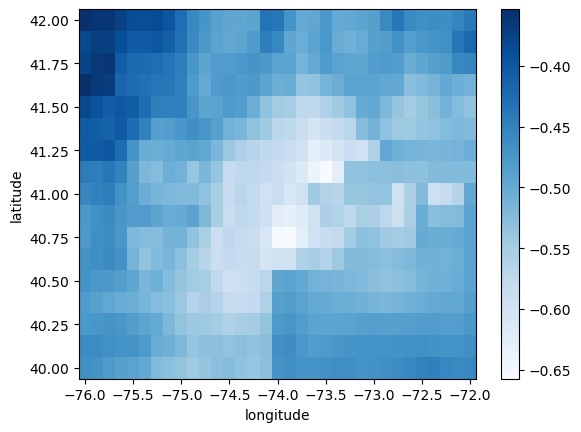

In [377]:
da_error_index.mean(axis=0).sel(latitude=slice(42,40), longitude=slice(-76,-72)).plot(cmap='Blues')

In [338]:
def samples_to_da(x, shape):
    '''
    Given a list of sample vectors x, recontruct an appropriate data array
    '''
    i, j, k = shape
    errors = x[:,0]
    lats = x[:,1]
    lons = x[:,2]
    times = x[:,3]
    
    errors = np.reshape(np.reshape(errors, (j*k, i)).T, (i, j, k))
    lats = np.reshape(np.reshape(lats, (j*k, i)).T, (i, j, k))
    lons = np.reshape(np.reshape(lons, (j*k, i)).T, (i, j, k))
    times = np.reshape(np.reshape(times, (j*k, i)).T, (i, j, k))

    da_reconstructed = xr.DataArray(
        errors,
        coords=[times[:, 0, 0], lats[0, :, 0], lons[0, 0, :]],
        dims=['time', 'latitude', 'longitude']
    )
    return da_reconstructed

In [3]:
# Prepare training samples
samples = np.stack([
                    da_error.stack(newdim=['latitude','longitude','time']).values,
                    da_error.stack(newdim=['latitude','longitude','time']).latitude.values,
                    da_error.stack(newdim=['latitude','longitude','time']).longitude.values,
                    da_error.stack(newdim=['latitude','longitude','time']).time.values
                ], axis=1)
print(samples[0])
print(samples.shape)

[ -1.3796146  45.        -85.          1.       ]
(303831, 4)


In [4]:
# Normalize
def normalize(x):
    y = np.ones_like(x)
    y[:,0] = x[:,0] # error
    y[:,1] = (x[:,1] - x[:,1].min()) / (x[:,1].max() - x[:,1].min()) # lat
    y[:,2] = (np.cos(x[:,2]/360*2*np.pi)+1)/2 # lon (cyclic normalized)
    y[:,3] = (np.sin(x[:,3]/365*2*np.pi)+1)/2 # day of year (cyclic normalized)
    return y

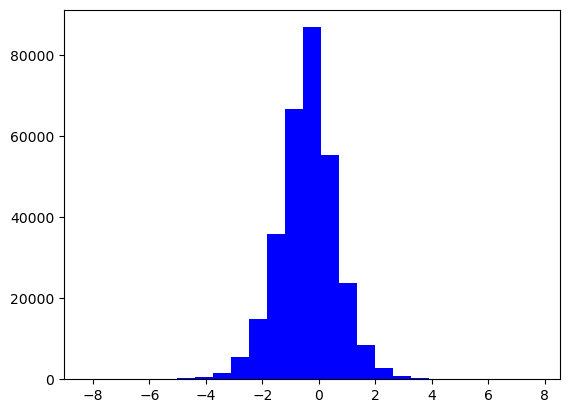

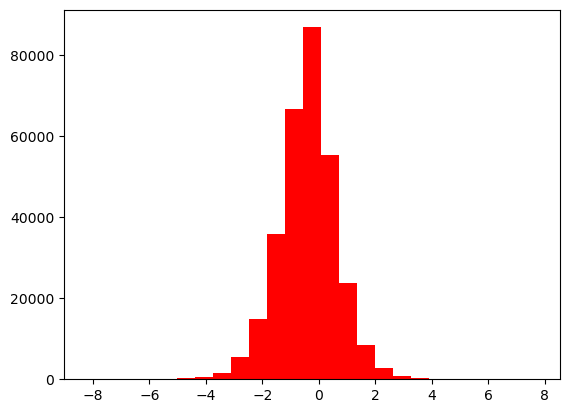

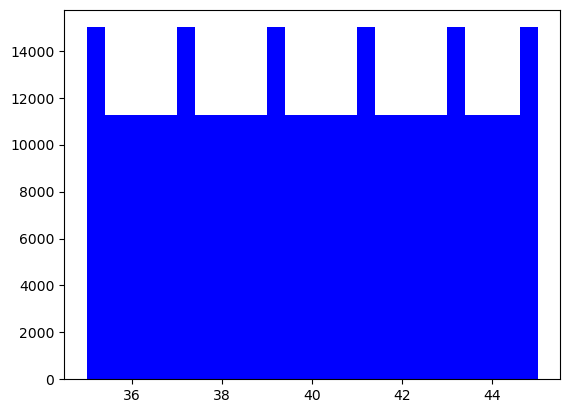

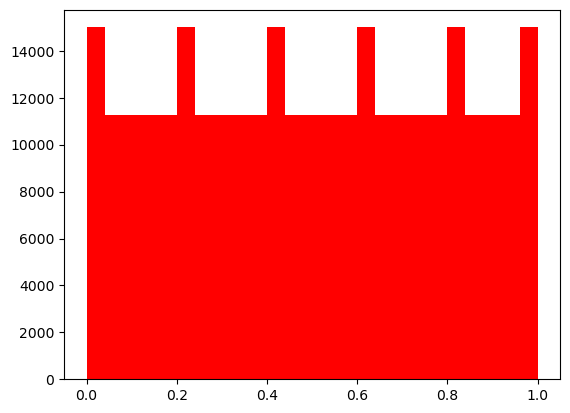

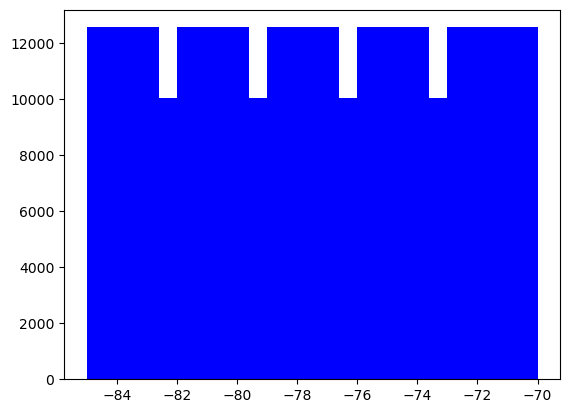

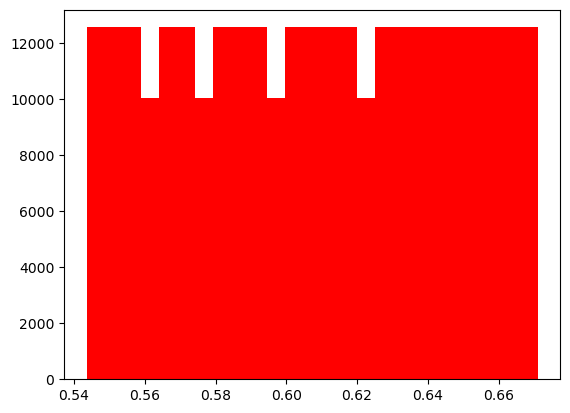

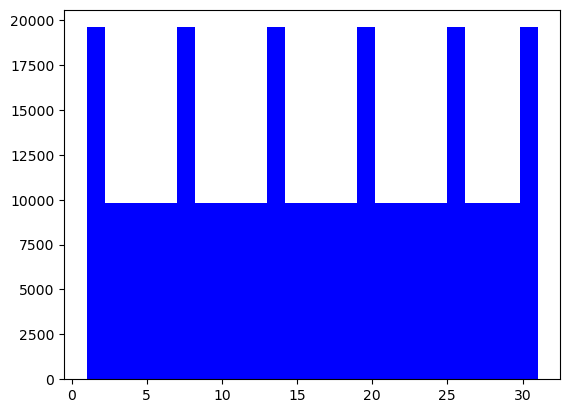

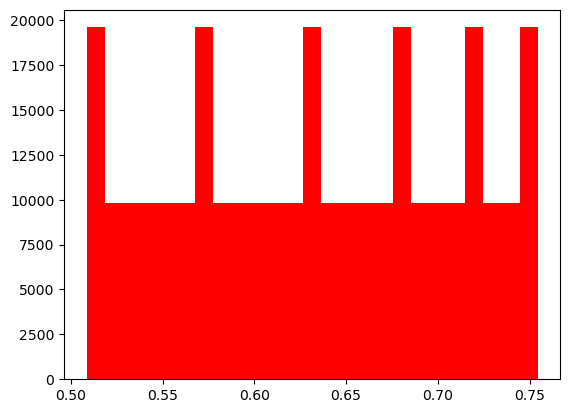

In [5]:
# Check normalization
for i in range(4):
    plt.hist(samples[:,i], color='b', bins=25)
    plt.show()
    plt.hist(normalize(samples)[:,i], color='r', bins=25)
    plt.show()

In [6]:
# Define torch dataset
class CustomDataset(Dataset):
    
    def __init__(self, data_input):
        """
        Most basic pytorch dataset for autoencoder
        
        Args:
            data_input (array): input images
        """
        self.img_train = data_input

    def __len__(self):
        return len(self.img_train)

    def __getitem__(self, idx):
        image = self.img_train[idx]
        return {'input': image, 'label': image}

In [7]:
# Split data and create datasets and dataloaders
x_train_raw, x_test_raw = train_test_split(samples, test_size=0.1, random_state=0, shuffle=True)
x_train_raw, x_valid_raw = train_test_split(x_train_raw, test_size=0.1, random_state=0, shuffle=True)

x_train = normalize(x_train_raw)
x_valid = normalize(x_valid_raw)
x_test = normalize(x_test_raw)

train_data = CustomDataset(x_train)
valid_data = CustomDataset(x_valid)
test_data = CustomDataset(x_test)

train_dataloader = DataLoader(train_data, batch_size=16, shuffle=True)
valid_dataloader = DataLoader(valid_data, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=len(test_data), shuffle=False)

In [8]:
# Sanity checks
print(train_data.__getitem__(0))
for i in train_dataloader:
    print(i['input'].shape)
    break

{'input': array([-0.34295322,  0.175     ,  0.67101007,  0.73936692]), 'label': array([-0.34295322,  0.175     ,  0.67101007,  0.73936692])}
torch.Size([16, 4])


## Build Model

In [9]:
class AE(nn.Module):
    
    def __init__(self, **kwargs):
        
        super().__init__()
        
        self.encoder_hidden_layer = nn.Linear(
            in_features=4, out_features=2
        )
        self.encoder_output_layer = nn.Linear(
            in_features=2, out_features=1
        )
        self.decoder_hidden_layer = nn.Linear(
            in_features=1, out_features=2
        )
        self.decoder_output_layer = nn.Linear(
            in_features=2, out_features=4
        )

    def forward(self, features):
        
        activation = self.encoder_hidden_layer(features)
        activation = torch.relu(activation)
        
        code = self.encoder_output_layer(activation)
        
        activation = self.decoder_hidden_layer(code)
        activation = torch.relu(activation)
        
        activation = self.decoder_output_layer(activation)
        reconstructed = torch.relu(activation)
        
        return reconstructed

    def encode(self, features):
        
        activation = self.encoder_hidden_layer(features)
        activation = torch.relu(activation)
        
        code = self.encoder_output_layer(activation)
        
        return code

In [10]:
def train(model, dataloader, criterion):
    """
    Training function.
    Args:
        model (torch): pytorch neural network
        dataloader (torch): pytorch dataloader
        criterion: loss
    """
    model.train()
    running_loss = 0.0
    
    for data in dataloader:
        
        img_input = data['input']
        img_label = data['label']

        outputs = model(img_input.float())
        
        loss = criterion(outputs, img_label.float())
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    train_loss = running_loss / len(dataloader)
    
    return train_loss

In [11]:
def validate(model, dataloader, criterion):
    """
    Training function.
    Args:
        model (torch): pytorch neural network
        dataloader (torch): pytorch dataloader
        criterion: loss
    """
    model.eval()
    
    running_loss = 0.0
    
    with torch.no_grad():
    
        for data in dataloader:
            
            img_input = data['input']
            img_label = data['label']
    
            outputs = model(img_input.float())
            
            loss = criterion(outputs, img_label.float())
            
            running_loss += loss.item()
    
    train_loss = running_loss / len(dataloader)
    
    return train_loss

In [12]:
model = AE()

In [13]:
LEARNING_RATE = 1e-4

# the optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# the loss function
criterion = torch.nn.MSELoss()

In [ ]:
NUM_EPOCHS = 10
train_loss = []
valid_loss = []

for enum, epoch in enumerate(range(NUM_EPOCHS)):
    
    t_loss = train(model, train_dataloader, criterion)
    v_loss = validate(model, valid_dataloader, criterion)
    train_loss.append(t_loss)
    valid_loss.append(v_loss)
    
    print(f"Epoch {epoch + 1} of {NUM_EPOCHS}; Train Loss: {t_loss:.4f}, Validation Loss: {v_loss:.4f}")

In [ ]:
plt.plot(train_loss)
#plt.savefig('AE_train_curve.png')
plt.show()

In [15]:
test_data.__getitem__(0)

{'input': array([-1.12751897,  0.7       ,  0.56850617,  0.72411467]),
 'label': array([-1.12751897,  0.7       ,  0.56850617,  0.72411467])}

## Kyle's Version

In [12]:
class Autoencoder(nn.Module):
    def __init__(self, bottleneck_dim=1,  lr=0.001, verbose=True, activation=nn.Sigmoid, hidden_layers=[], decoder_hidden_layers=None):
        super(Autoencoder, self).__init__()
        self.fitted = False
        self.lr = lr
        self.hidden_layers = hidden_layers
        self.decoder_hidden_layers = hidden_layers[::-1] if decoder_hidden_layers is None else decoder_hidden_layers
        self.activation = activation
        self.verbose = verbose
        self.bottleneck_dim = bottleneck_dim

    def forward(self, x):
        encoded = self.encoder(x)
        encoded.requires_grad_()
        decoded = self.decoder(encoded)
        return encoded, decoded

    def transform(self, x):
        data_np = x.astype(np.float32)
        data_tensor = torch.tensor(data_np, dtype=torch.float32)
        with torch.no_grad():
            encoded, test_output = self(data_tensor)
        return test_output.detach().numpy()

    def encode(self, x): 
        data_np = x.astype(np.float32)
        data_tensor = torch.tensor(data_np, dtype=torch.float32)
        with torch.no_grad():
            encoded, test_output = self(data_tensor)
        return encoded.detach().numpy()


    def fit(self, x, num_epochs=30, batch_size=32, patience=5, outpath='best_model.pth'):
        assert len(list(x.shape)) == 2, 'we need 2D data here people - do the stackin yourself'
        self.input_dim = x.shape[1]

        self.hidden_layers.insert(0, self.input_dim)        
        self.decoder_hidden_layers.insert(0, self.bottleneck_dim)

        # construct encoder 
        if len(self.hidden_layers) == 0:
            self.encoder = nn.Sequential(nn.Linear(self.input_dim, self.bottleneck_dim))
        else:
            enc = []
            while len(self.hidden_layers) > 1: 
                enc.append(nn.Linear(self.hidden_layers[0], self.hidden_layers[1]))
                enc.append(self.activation())
                self.hidden_layers.pop(0)
            enc.append(nn.Linear( self.hidden_layers[0], self.bottleneck_dim))
            self.encoder = nn.Sequential(*enc)


        # construct decoder 
        if len(self.decoder_hidden_layers) == 0:
            self.decoder = nn.Sequential(nn.Linear(self.bottleneck_dim, self.input_dim))
        else:
            dec = []
            while len(self.decoder_hidden_layers) > 1: 
                dec.append(nn.Linear(self.decoder_hidden_layers[0], self.decoder_hidden_layers[1]))
                dec.append(self.activation())
                self.decoder_hidden_layers.pop(0)
            dec.append(nn.Linear( self.decoder_hidden_layers[0], self.input_dim))
            self.decoder = nn.Sequential(*dec)


        data_np = x.astype(np.float32)
        data_tensor = torch.tensor(data_np, dtype=torch.float32)
        train_loader = torch.utils.data.DataLoader(dataset=data_tensor, batch_size=batch_size, shuffle=True)

        self.criterion = nn.MSELoss()  # Mean Squared Error Loss
        self.optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)

        training_losses = []
        validation_losses = []
        best_loss = float('inf')
        patience_counter = 0

        for epoch in range(num_epochs):
            self.train()
            running_loss = 0.0

            for batch in train_loader:
                self.optimizer.zero_grad()
                encoded, decoded = self(batch)
                loss = self.criterion(decoded, batch)
                loss.backward()
                self.optimizer.step()
                loss_array = loss.item()
                running_loss += loss_array * float(batch.size(0))
            epoch_train_loss = running_loss / len(train_loader.dataset)
            training_losses.append(epoch_train_loss)

            if self.verbose:
                print(f'Epoch [{epoch + 1}/{num_epochs}] -- Loss: {epoch_train_loss:.4f}', end='\r')

            if epoch_train_loss < best_loss:
                best_loss = epoch_train_loss
                patience_counter = 0
                torch.save(self.state_dict(), outpath)
            else:
                patience_counter += 1
            
            if patience_counter >= patience:
                print('\nEarly stopping triggered.')
                break

            if np.isnan(loss.item()):
                break
            

        if self.verbose:
            print('\nTraining complete!')

        self.fitted = True
        self.load_state_dict(torch.load(outpath))

        return np.asarray(training_losses)

In [14]:
# Train model
layer_sizes=[8,4,2] 

model = Autoencoder(bottleneck_dim=1,  lr=0.01, verbose=True, activation=nn.Sigmoid, hidden_layers=layer_sizes)
training_losses = model.fit(x_train, num_epochs=2, batch_size=16, patience=5, outpath='best_model.pth')

Epoch [2/2] -- Loss: 0.0232
Training complete!


/glade/derecho/scratch/dcalhoun/tmp/ipykernel_51493/243610451.py:115: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(outpath))


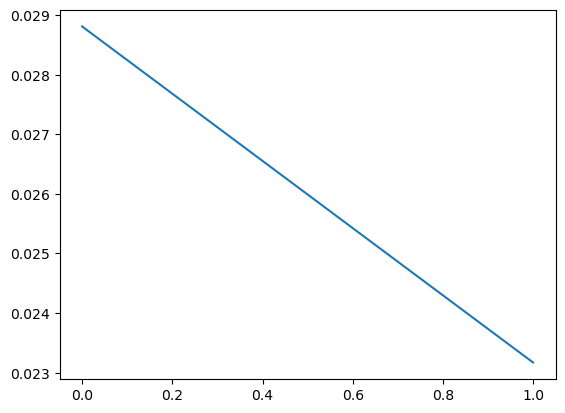

In [15]:
# Plot training curve
plt.plot(training_losses)
plt.show()

In [16]:
# Index and evaluation
index_train = model.encode(x_train)
index_valid = model.encode(x_valid) 
index_test = model.encode(x_test) 

x_train_rec = model.transform(x_train)
x_valid_rec = model.transform(x_valid)
x_test_rec = model.transform(x_test)

fc_error_train, lat_train, lon_train, day_train = np.unstack(x_train_raw, axis=1)
fc_error_valid, lat_valid, lon_valid, day_valid = np.unstack(x_valid_raw, axis=1)
fc_error_test, lat_test, lon_test, day_test = np.unstack(x_test_raw, axis=1)

fc_error_train_rec = np.unstack(x_train_rec, axis=1)[0]
fc_error_valid_rec = np.unstack(x_valid_rec, axis=1)[0]
fc_error_test_rec = np.unstack(x_test_rec, axis=1)[0]

In [73]:
samples_norm = normalize(samples)
samples_rec = model.transform(samples_norm)
samples_index = model.encode(samples_norm)

In [17]:
test_RMSE = np.sqrt(np.sum((fc_error_test - fc_error_test_rec)**2)/len(x_test))
test_RMSE

np.float64(0.029919057867839112)

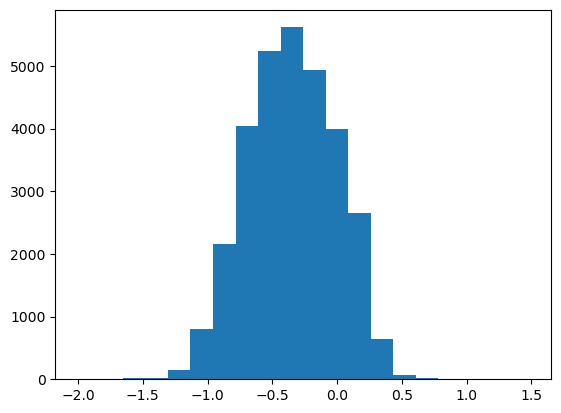

In [18]:
plt.hist(index_test, bins=20)
plt.show()

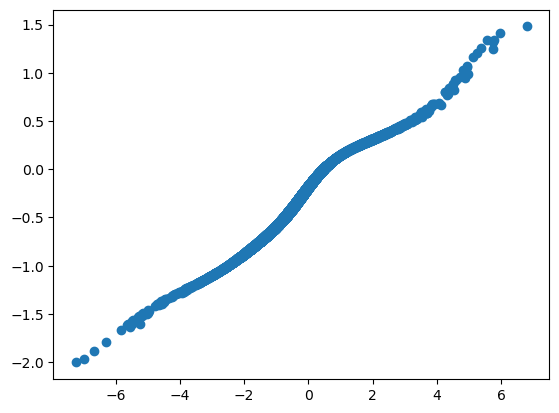

In [19]:
plt.scatter(fc_error_test, index_test)
plt.show()

In [ ]:
# da_error_test_rec_copy = da_error_test_rec
# da_error_test_rec_copy.loc[{'latitude': lat_test, 'longitude': lon_test, 'time': day_test}] = fc_error_test_rec

In [28]:
# Reconstruct data array
da_error_train_rec = xr.full_like(da_error, np.nan)
da_error_valid_rec = xr.full_like(da_error, np.nan)
da_error_test_rec = xr.full_like(da_error, np.nan)
for i in range(len(x_test)):
    da_error_test_rec.loc[{'latitude': lat_test[i], 'longitude': lon_test[i], 'time': day_test[i]}] = fc_error_test_rec[i]
    if i % 100 == 0:
        print(i, '/', len(x_test), f'{i/len(x_test)*100: .2f}%', end='\r')

In [146]:
fc_error_samples, lat_samples, lon_samples, time_samples = np.unstack(samples, axis=1)

fc_error_samples_rec = np.unstack(samples_rec, axis=1)[0]

In [175]:
samples_rec_copy = np.stack([fc_error_samples_rec, lat_samples, lon_samples, time_samples], axis=1)

In [219]:
da_error.longitude.values.shape

(121,)

In [258]:
for i in range(121*31*81):
    if i % 31 == 30:
        if ((i // 31) % 121) == 120:
            if i // (31*121) == 0:
                print(samples_rec_copy[i])

[ -0.44393042  45.         -70.          31.        ]


In [286]:
samples[:,0]

array([-1.3796146 , -0.60975467, -1.16533736, ...,  0.33671641,
        0.1586073 ,  0.0947602 ])

In [315]:
np.reshape(samples[:,0], (121*81, 31)).T.shape

(31, 9801)

In [ ]:
np.reshape(np.reshape(fc_error_samples_rec, (121*81, 31)).T, (31, 81, 121))[0]

In [318]:
np.reshape(np.reshape(samples[:,0], (121*81, 31)).T, (31, 81, 121))

array([[[-1.37961460e+00, -1.30035271e+00, -1.21794029e+00, ...,
         -2.12158886e+00, -2.13707746e+00, -2.32121569e+00],
        [-1.42389468e+00, -1.33898738e+00, -1.26559500e+00, ...,
         -3.00924635e+00, -2.96005824e+00, -3.13030789e+00],
        [-1.40043904e+00, -1.32438281e+00, -1.26089876e+00, ...,
         -5.29552030e+00, -4.26899118e+00, -3.60780363e+00],
        ...,
        [-4.30167847e-01, -5.13118334e-01, -5.59037507e-01, ...,
          3.10518412e-01,  1.18226509e-01, -1.17681797e-01],
        [-4.24816484e-01, -4.69856850e-01, -5.18679200e-01, ...,
         -1.74048844e-01, -3.47853183e-01, -3.93996572e-01],
        [-4.28548432e-01, -4.63135306e-01, -4.91071131e-01, ...,
         -6.67465295e-01, -5.44479314e-01, -4.83808273e-01]],

       [[-6.09754666e-01, -6.52374916e-01, -7.33283966e-01, ...,
         -3.23556293e+00, -2.55944737e+00, -2.22548180e+00],
        [-5.68396212e-01, -5.44347356e-01, -6.16817363e-01, ...,
         -3.54654765e+00, -3.53527668e

In [312]:
np.reshape(samples[:,0], (121*81, 31)).T

array([[-1.3796146 , -1.30035271, -1.21794029, ..., -0.6674653 ,
        -0.54447931, -0.48380827],
       [-0.60975467, -0.65237492, -0.73328397, ...,  0.24264968,
         0.21301962,  0.16088988],
       [-1.16533736, -1.15701287, -1.13103234, ...,  0.15683816,
         0.15541323,  0.1605885 ],
       ...,
       [-0.56655724, -0.58614447, -0.50035456, ...,  0.14761114,
         0.2409931 ,  0.33671641],
       [-0.19606642, -0.24203046, -0.29652612, ...,  0.05699981,
         0.17500796,  0.1586073 ],
       [-1.84576418, -1.90312769, -2.04945686, ...,  0.08827534,
         0.08439977,  0.0947602 ]])

In [ ]:
for i in range(121*31*81):
    if i % 3050 == 1:
        print(i % 31, ((i // 31) % 121), i // (31*121)) # day, lon, lat (indices)

In [160]:
# Reshape the extracted components to match the original shape of 'da_error'
# Assuming the original 'da_error' had shape (n_lat, n_lon, n_time)
# You might need to adjust the shape based on how you flattened and stacked your array

n_lat = len(np.unique(lat_samples))  # Number of unique latitudes
n_lon = len(np.unique(lon_samples))  # Number of unique longitudes
n_time = len(np.unique(day_samples))  # Number of unique time points

# Reshape the values back into the original 3D shape (latitude, longitude, time)
data_reshaped = fc_error_samples_rec.reshape((n_time, n_lat, n_lon))
latitudes_reshaped = lat_samples.reshape((n_time, n_lat, n_lon))
longitudes_reshaped = lon_samples.reshape((n_time, n_lat, n_lon))
times_reshaped = time_samples.reshape((n_time, n_lat, n_lon))

# Create a new DataArray using the reshaped components
da_error_reconstructed = xr.DataArray(
    data_reshaped,
    coords=[times_reshaped[:, 0, 0], latitudes_reshaped[0, :, 0], longitudes_reshaped[0, 0, :]],
    dims=['time', 'latitude', 'longitude']
)

In [ ]:
da_error_samples_rec = xr.full_like(da_error, np.nan)
for sample in np.stack([fc_error_samples_rec, lat_samples, lon_samples, day_samples], axis=1):
    error = sample[0]
    lat_idx = lat_dict[sample[1]]
    lon_idx = lon_dict[sample[2]]
    time_idx = time_dict[sample[3]]
    da_error_samples_rec[time_idx, lat_idx, lon_idx] = error

In [ ]:
da_error_samples_rec = xr.full_like(da_error, np.nan)
for lat in lat_samples:
    for lon in lon_samples:
        for time in day_samples:
            da_error_samples_rec[lat_dict[lat], lon_dict[lon], time_dict[time]] = fc_error_test_rec
    da_error_test_rec.loc[{'latitude': lat_test[i], 'longitude': lon_test[i], 'time': day_test[i]}] = fc_error_test_rec[i]
    if i % 100 == 0:
        print(i, '/', len(x_test), f'{i/len(x_test)*100: .2f}%', end='\r')

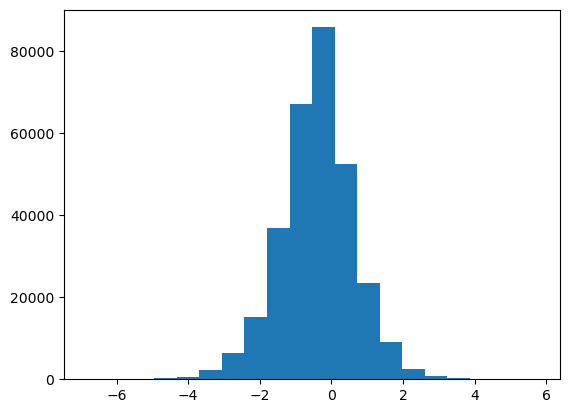

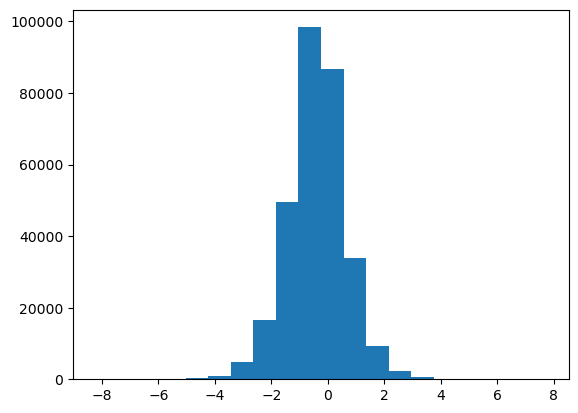

In [79]:
plt.hist(fc_error_samples_rec, bins=20)
plt.show()
plt.hist(fc_error_samples, bins=20)
plt.show()

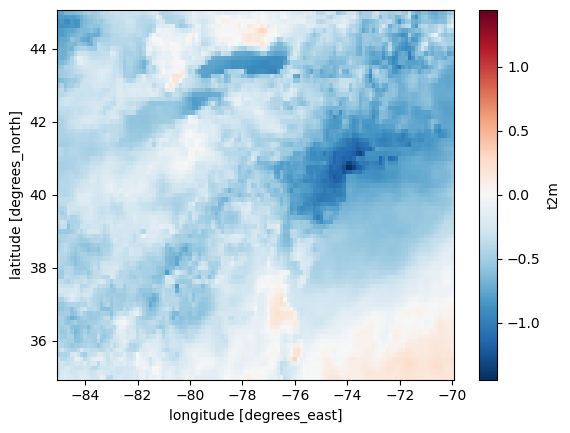

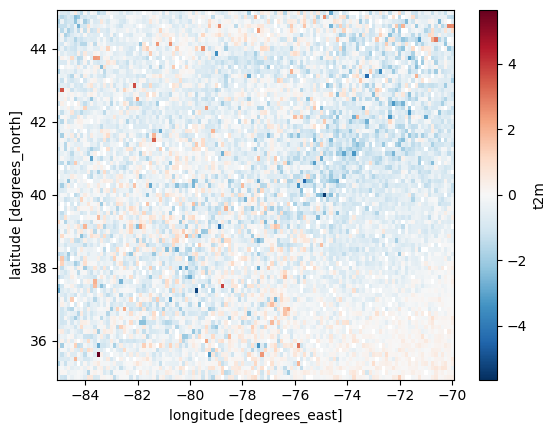

In [52]:
da_error.mean(axis=0).plot()
plt.show()
da_error_test_rec.mean(axis=0).plot()
plt.show()

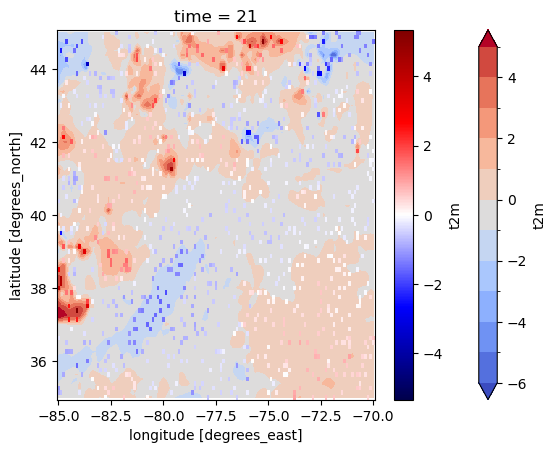

In [48]:
da_error[20].plot.contourf(levels=np.arange(-6,6), cmap='coolwarm')
da_error_test_rec[20].plot(cmap='seismic')
plt.show()

In [130]:
lat_idx_test = [np.where(da_error_test_rec.latitude == lat_test[i])[0][0] for i in range(len(x_test))]
lon_idx_test = [np.where(da_error_test_rec.longitude == lon_test[i])[0][0] for i in range(len(x_test))]
time_idx_test = [np.where(da_error_test_rec.time == day_test[i])[0][0] for i in range(len(x_test))]

In [ ]:
da_error_test_rec[time_idx_test, lat_idx_test, lon_idx_test] = fc_error_test_rec

In [ ]:
da_error_test_rec.values

In [ ]:
da_error_reconstructed[20].plot()
# da_error[20].plot.contourf()
plt.show()

In [ ]:
ds = xr.Dataset(
    {
        "t2m": (["latitude", "longitude", "day"], fc_error_rec),
    },
    coords={
        "latitude": (["latitude"], lat),
        "longitude": (["longitude"], lon),
        "day": day,
    },
)


## Convolution

In [ ]:
# consider each 

In [ ]:
# https://www.digitalocean.com/community/tutorials/convolutional-autoencoder

In [ ]:
#  defining encoder
    class Encoder(nn.Module):
      def __init__(self, in_channels=3, out_channels=16, latent_dim=200, act_fn=nn.ReLU()):
        super().__init__()
    
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1), # (32, 32)
            act_fn,
            nn.Conv2d(out_channels, out_channels, 3, padding=1), 
            act_fn,
            nn.Conv2d(out_channels, 2*out_channels, 3, padding=1, stride=2), # (16, 16)
            act_fn,
            nn.Conv2d(2*out_channels, 2*out_channels, 3, padding=1),
            act_fn,
            nn.Conv2d(2*out_channels, 4*out_channels, 3, padding=1, stride=2), # (8, 8)
            act_fn,
            nn.Conv2d(4*out_channels, 4*out_channels, 3, padding=1),
            act_fn,
            nn.Flatten(),
            nn.Linear(4*out_channels*8*8, latent_dim),
            act_fn
        )
    
      def forward(self, x):
        x = x.view(-1, 3, 32, 32)
        output = self.net(x)
        return output
    
    
    #  defining decoder
    class Decoder(nn.Module):
      def __init__(self, in_channels=3, out_channels=16, latent_dim=200, act_fn=nn.ReLU()):
        super().__init__()
    
        self.out_channels = out_channels
    
        self.linear = nn.Sequential(
            nn.Linear(latent_dim, 4*out_channels*8*8),
            act_fn
        )
    
        self.conv = nn.Sequential(
            nn.ConvTranspose2d(4*out_channels, 4*out_channels, 3, padding=1), # (8, 8)
            act_fn,
            nn.ConvTranspose2d(4*out_channels, 2*out_channels, 3, padding=1, 
                               stride=2, output_padding=1), # (16, 16)
            act_fn,
            nn.ConvTranspose2d(2*out_channels, 2*out_channels, 3, padding=1),
            act_fn,
            nn.ConvTranspose2d(2*out_channels, out_channels, 3, padding=1, 
                               stride=2, output_padding=1), # (32, 32)
            act_fn,
            nn.ConvTranspose2d(out_channels, out_channels, 3, padding=1),
            act_fn,
            nn.ConvTranspose2d(out_channels, in_channels, 3, padding=1)
        )
    
      def forward(self, x):
        output = self.linear(x)
        output = output.view(-1, 4*self.out_channels, 8, 8)
        output = self.conv(output)
        return output
    
    
    #  defining autoencoder
    class Autoencoder(nn.Module):
      def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.encoder.to(device)
    
        self.decoder = decoder
        self.decoder.to(device)
    
      def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [ ]:
class ConvolutionalAutoencoder():
      def __init__(self, autoencoder):
        self.network = autoencoder
        self.optimizer = torch.optim.Adam(self.network.parameters(), lr=1e-3)
    
      def train(self, loss_function, epochs, batch_size, 
                training_set, validation_set, test_set):
        
        #  creating log
        log_dict = {
            'training_loss_per_batch': [],
            'validation_loss_per_batch': [],
            'visualizations': []
        } 
    
        #  defining weight initialization function
        def init_weights(module):
          if isinstance(module, nn.Conv2d):
            torch.nn.init.xavier_uniform_(module.weight)
            module.bias.data.fill_(0.01)
          elif isinstance(module, nn.Linear):
            torch.nn.init.xavier_uniform_(module.weight)
            module.bias.data.fill_(0.01)
    
        #  initializing network weights
        self.network.apply(init_weights)
    
        #  creating dataloaders
        train_loader = DataLoader(training_set, batch_size)
        val_loader = DataLoader(validation_set, batch_size)
        test_loader = DataLoader(test_set, 10)
    
        #  setting convnet to training mode
        self.network.train()
        self.network.to(device)
    
        for epoch in range(epochs):
          print(f'Epoch {epoch+1}/{epochs}')
          train_losses = []
    
          #------------
          #  TRAINING
          #------------
          print('training...')
          for images in tqdm(train_loader):
            #  zeroing gradients
            self.optimizer.zero_grad()
            #  sending images to device
            images = images.to(device)
            #  reconstructing images
            output = self.network(images)
            #  computing loss
            loss = loss_function(output, images.view(-1, 3, 32, 32))
            #  calculating gradients
            loss.backward()
            #  optimizing weights
            self.optimizer.step()
    
            #--------------
            # LOGGING
            #--------------
            log_dict['training_loss_per_batch'].append(loss.item())
    
          #--------------
          # VALIDATION
          #--------------
          print('validating...')
          for val_images in tqdm(val_loader):
            with torch.no_grad():
              #  sending validation images to device
              val_images = val_images.to(device)
              #  reconstructing images
              output = self.network(val_images)
              #  computing validation loss
              val_loss = loss_function(output, val_images.view(-1, 3, 32, 32))
    
            #--------------
            # LOGGING
            #--------------
            log_dict['validation_loss_per_batch'].append(val_loss.item())
    
    
          #--------------
          # VISUALISATION
          #--------------
          print(f'training_loss: {round(loss.item(), 4)} validation_loss: {round(val_loss.item(), 4)}')
    
          for test_images in test_loader:
            #  sending test images to device
            test_images = test_images.to(device)
            with torch.no_grad():
              #  reconstructing test images
              reconstructed_imgs = self.network(test_images)
            #  sending reconstructed and images to cpu to allow for visualization
            reconstructed_imgs = reconstructed_imgs.cpu()
            test_images = test_images.cpu()
    
            #  visualisation
            imgs = torch.stack([test_images.view(-1, 3, 32, 32), reconstructed_imgs], 
                              dim=1).flatten(0,1)
            grid = make_grid(imgs, nrow=10, normalize=True, padding=1)
            grid = grid.permute(1, 2, 0)
            plt.figure(dpi=170)
            plt.title('Original/Reconstructed')
            plt.imshow(grid)
            log_dict['visualizations'].append(grid)
            plt.axis('off')
            plt.show()
          
        return log_dict
    
      def autoencode(self, x):
        return self.network(x)
    
      def encode(self, x):
        encoder = self.network.encoder
        return encoder(x)
      
      def decode(self, x):
        decoder = self.network.decoder
        return decoder(x)

## Lapenta CNN

        #!/scratch1/NCEPDEV/mdl/Dean.Calhoun/miniconda3/envs/tf-gpu/bin/python
        
        # Author: Mamoudou Ba - May 2019 -
        # This code is adopted from Jim Biard's code of Automated detection of weather fronts 
        # using deep learning neural network. This application is a convolutional neural network for
        # forecast probabilities of storm based using the HRRR fields as inputs
        # Jim Biard was instrumental to prototyping this application
        # The function weighted_categorical_crossentropy is obtained from 
        # https://gist.github.com/wassname/ce364fddfc8a025bfab4348cf5de852d
        #
        import os
        
        # Import the needed libraries
        #import seaborn as sns
        import numpy as np
        import numpy.ma as ma
        import matplotlib.pyplot as plt
        #import netCDF4
        #from netCDF4 import Dataset
        from datetime import datetime
        import dateutil.parser
        from tensorflow import keras
        import tensorflow as tf
        from tensorflow.keras.utils import to_categorical
        
        from tensorflow.keras import backend
        from tensorflow.keras import callbacks
        from tensorflow.keras.backend import int_shape
        from tensorflow.keras.initializers import Initializer
        from tensorflow.keras.models import Sequential
        
        from tensorflow.keras.layers import Conv2D, Input, SpatialDropout2D, ZeroPadding2D
        from tensorflow.keras.optimizers import Adam
        from sklearn.model_selection import GridSearchCV, ParameterGrid
        from tensorflow.keras.callbacks import ModelCheckpoint
        #from memory_profiler import profile
        
        
        # Import `train_test_split` from `sklearn.model_selection`
        from sklearn.model_selection import train_test_split
        
        from sklearn.preprocessing import StandardScaler
        from sklearn.utils import class_weight
        #from tensorflow.keras.models import load_model
        
        import tensorflow.keras.backend as K
        from itertools import product
        from tensorflow.keras import activations
        
        
        import zarr
        
        
        # Import `Sequential` from `keras.models`
        from tensorflow.keras.models import Sequential
        
        ##################################
        #Configuration of GPU Options
        # TensorFlow wizardry
        os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
        
        config = tf.compat.v1.ConfigProto()
         
        # Don't pre-allocate memory; allocate as-needed
        config.gpu_options.allow_growth = True
         
        # Only allow a total of half the GPU memory to be allocated
        config.gpu_options.per_process_gpu_memory_fraction = 0.4
        
        #sess = tf.Session() 
        #sess = tf.compat.v1.Session() 
        tf.compat.v1.keras.backend.set_session(tf.compat.v1.Session(config=config));
        
        
        now = datetime.now()
        
        current_time = now.strftime("%H:%M:%S")
        print("Beginning Time for 1 node = ", current_time)
        
        
        os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # suppress most messages
        
        
        print("********Num GPUs Available: *******", len(tf.config.list_physical_devices('GPU')))
        
        # Initializing data arrays
        #
        nx, ny = (501, 251)
        
        
        i = 0
        
        
        def weighted_categorical_crossentropy(weights):
            """
            A weighted version of keras.objectives.categorical_crossentropy
            
            Variables:
                weights: numpy array of shape (C,) where C is the number of classes
            
            Usage:
                weights = np.array([0.5,2,10]) # Class one at 0.5, class 2 twice the normal weights, class 3 10x.
                loss = weighted_categorical_crossentropy(weights)
                model.compile(loss=loss,optimizer='adam')
            """
            
            weights = K.variable(weights)
                
            def loss(y_true, y_pred):
                # scale predictions so that the class probas of each sample sum to 1
                y_pred /= K.sum(y_pred, axis=-1, keepdims=True)
                # clip to prevent NaN's and Inf's
                y_pred = K.clip(y_pred, K.epsilon(), 1 - K.epsilon())
                # calc
                loss = y_true * K.log(y_pred) * weights
                loss = -K.sum(loss, -1)
                return loss
            
            return loss
        
        
        
        def softmaxND(x):
            '''
            Calculate the softmax measure on the input tensor with an arbitrary number
            of dimensions.
            
            x [in]  A Theano Tensor object where the last dimension is the category
                    dimension.
            returns A Theano Tensor object of the same dimensions with softmax results.
            '''
            
            # Get the shape of the tensor.
            #
            theShape = backend.shape(x)
            
            # Reshape the tensor to make it 2D.
            #
            firstDim = backend.prod(theShape[0:-1])
        
            in2D = backend.reshape(x, (firstDim, theShape[-1]))
            
            # Get the softmax.
            #
            out2D = backend.softmax(in2D)
            
            # Return the output to the original shape.
            #
            outND = backend.reshape(out2D, theShape)
            
            # Return the result tensor.
            #
            return outND
        
        #
        class biasInit(Initializer):
            def __call__(self, shape, dtype = None):
                '''
                Create a bias vector that has all but the last element equal to 0.01,
                except for the last element, which will equal 1.0 - (n-1)*0.01, where n is
                last size value in the shape vector.
        
                shape [in] The shape for the bias vector.
                dtype [in] The data type for the bias vector.
                returns    A bias vector.
                '''
        
                # Create an array of the right length with all values equal to 0.01
                # except for the last element, which will equal 1.0 - (n-1)*0.01.
                #
                values = np.zeros(shape, dtype = np.float32)
                
                values[...] = 0.01
                values[-1]  = 1.0 - 0.01 * shape[-1]
                
                # Create a constant tensor with the bias values.
                #
                bias = backend.constant(values, dtype = dtype, shape = shape)
                
                # Return the bias vector.
                #
                return bias
        
        #  Reading data and creating training and label sets
        #Looping over months
        
        inputs = zarr.open_array('/scratch1/NCEPDEV/mdl/Dean.Calhoun/zarr_input_13_var_2016_2022_f01', mode = 'r')
        labels = zarr.open_array('/scratch1/NCEPDEV/mdl/Dean.Calhoun/zarr_label_13_var_2016_2022_f01', mode = 'r')
        
        
        
        batch_size = inputs.chunks[0]
        num_chunks = inputs.nchunks
        # Get an array with the indices of the start of each batch chunk.
        #
        time_indices = batch_size * np.arange(0, num_chunks)
        
        # Randomize the time indices.
        #
        rng = np.random.default_rng()
        rng.shuffle(time_indices)
        
        rng.shuffle(time_indices)
        
        num_times  = inputs.shape[0]
        
        batch_size = inputs.chunks[0]
        num_chunks = inputs.nchunks
        
        print(batch_size, num_chunks)
        
        # Set the validation dataset to be the last 20% of the data.
        #
        # Get the index into the time indices for the validation split. This is also the number of training chunks.
        # Get the number of validation chunks.
        #
        validation_offset = int(8 * len(time_indices) / 10)
        validation_chunks = num_chunks - validation_offset
        
        
        print(inputs.shape[0], inputs.chunks)
        print(labels.shape[0], labels.chunks)
        
        def training_generator():
            while True:
              for i in time_indices[0:validation_offset]:
                  x = inputs[i:i+batch_size, ...]
                  y = labels[i:i+batch_size, ...]
                  yield (x,y)
        
        def validation_generator():
            while True:
              for i in time_indices[validation_offset:]:
                  x = inputs[i:i+batch_size, ...]
                  y = labels[i:i+batch_size, ...]
                  yield (x,y)
        
        
        
        
        # training the model
        
        # Initialize the constructor
        model = Sequential()
        
        input_shape = (251, 501, 13)
        filterSize = 5
        numLayers = 5
        lr = 0.0001
        numFilters = 80
        padSize = filterSize // 2
        activation = "relu"
        dropout = 0.20
        
        # Add an initial input layer.
        #
        
        #class_weights = {0:0.35, 1:5.0} 
        #sample_weight = np.zeros((279,701*1151))
        #sample_weight[:, 0] += 1
        #sample_weight[:, 1] += 10
        model.add(Input(shape = input_shape))
        
        # Calculate the number of pixels that must be added as a border around the
        # image, then add an initial layer that pads the output by that many
        # pixels. If the filterSize is not odd, raise an exception.
        #
        if (filterSize % 2) != 1:
             raise Exception('An even filterSize of ' + str(filterSize) + 'was specified')
                
        padSize = filterSize // 2
                
        model.add(ZeroPadding2D(padding = (padSize, padSize), data_format = 'channels_last'))
        
        # Add layer groups consisting of a convolution layer followed by a padding
        # layer to regrow the image to original size, then a dropout layer (if the
        # fraction is greater than 0.0).
        #
        
        for i in range(numLayers - 1):
              model.add(Conv2D(filters = numFilters, kernel_size = filterSize,
                    activation = activation, data_format = 'channels_last'))
              model.add(ZeroPadding2D(padding = (padSize, padSize), data_format = 'channels_last'))
        
              if dropout != 0.0:
                        model.add(SpatialDropout2D(dropout, data_format = 'channels_last'))
        
                    
        # Add a convolution layer that has a filter for each class
        # (includes one for 'no storm').
        #
        model.add(Conv2D(filters = 2, kernel_size = filterSize,
                                 activation = 'relu', data_format = 'channels_last'))
                
        # Add a 1x1 convolution layer that has a filter for each class of
        # (storm and no storm). Use the softmaxND activation function.
        #
        model.add(Conv2D(filters = 2, kernel_size = 1,
                         activation = softmaxND, data_format = 'channels_last',
                         bias_initializer = biasInit()))
        
        weights = np.array([0.1,1.0]) 
        
        #   Compile the model with custom loss function 
        
        model.compile(loss=weighted_categorical_crossentropy(weights),
                      optimizer=tf.keras.optimizers.Adam(learning_rate = lr),
                      metrics=['accuracy'])
        
        # Model output shape
        model.output_shape
        model.summary()
        model.get_config()
        epochs = 100
        
        history = model.fit(training_generator(), steps_per_epoch = validation_offset, validation_data=validation_generator(),
                           validation_steps=validation_chunks, epochs=epochs, verbose=1)
        
        #Saving trained model
        model.layers[-1].activation = softmaxND
        model.save('/scratch1/NCEPDEV/mdl/Dean.Calhoun/cnn_hrrr_13_var_2016_2022_f01.h5')
        
        np.save('/scratch1/NCEPDEV/mdl/Dean.Calhoun/cnn_hrrr_13_var_2016_2022_f01.npy',history.history)
        
        
        #print(scores)
        
        #print("%s: %.2f%% %s: %.2f%% %s: %.2f%%" % (model.metrics_names[0], scores[0]*100,model.metrics_names[1], scores[1]*100,model.metrics_names[2], scores[2]*100))
        print("Test score: ", scores[1])
        print("Test accuracy: ", scores[1])
        #list all data in history
        #print(history.history.keys())
        #summary history for accuracy
        plt.plot(history.history['accuracy'])
        plt.plot(history.history['val_accuracy'])
        plt.title('model accuracy')
        plt.ylabel('accuracy')
        plt.xlabel('epoch')
        plt.legend(['train', 'test'], loc='upper left')
        #plt.show()
        #plt.show()
        filename = 'cnn_accuracy.png'
         # Set the name of the variable to plot
        plt.savefig(filename) # Set the output file name
        plt.clf()
        plt.cla()
        plt.close()
        #summarize history for loss
        plt.plot(history.history['loss'])
        plt.plot(history.history['val_loss'])
        plt.title('model loss')
        plt.ylabel('loss')
        plt.xlabel('epoch')
        plt.legend(['train', 'test'], loc='upper left')
        #plt.show()
        filename = 'cnn_loss.png'
         # Set the name of the variable to plot
        plt.savefig(filename) # Set the output file name
        plt.clf()
        plt.cla()
        plt.close()
        
        now = datetime.now()
        
        current_time = now.strftime("%H:%M:%S")
        print("end Time for 1 node = ", current_time)
        
        #cnn()

## Cyclic normalization

In [57]:
dir = '/glade/campaign/collections/rda/data/d633000/e5.oper.an.sfc/'

In [58]:
files_foryr = sorted(glob.glob(f'{dir}201*/e5.oper.an.sfc.128_167_2t*.nc'))[:24]

In [59]:
files_foryr

['/glade/campaign/collections/rda/data/d633000/e5.oper.an.sfc/201001/e5.oper.an.sfc.128_167_2t.ll025sc.2010010100_2010013123.nc',
 '/glade/campaign/collections/rda/data/d633000/e5.oper.an.sfc/201002/e5.oper.an.sfc.128_167_2t.ll025sc.2010020100_2010022823.nc',
 '/glade/campaign/collections/rda/data/d633000/e5.oper.an.sfc/201003/e5.oper.an.sfc.128_167_2t.ll025sc.2010030100_2010033123.nc',
 '/glade/campaign/collections/rda/data/d633000/e5.oper.an.sfc/201004/e5.oper.an.sfc.128_167_2t.ll025sc.2010040100_2010043023.nc',
 '/glade/campaign/collections/rda/data/d633000/e5.oper.an.sfc/201005/e5.oper.an.sfc.128_167_2t.ll025sc.2010050100_2010053123.nc',
 '/glade/campaign/collections/rda/data/d633000/e5.oper.an.sfc/201006/e5.oper.an.sfc.128_167_2t.ll025sc.2010060100_2010063023.nc',
 '/glade/campaign/collections/rda/data/d633000/e5.oper.an.sfc/201007/e5.oper.an.sfc.128_167_2t.ll025sc.2010070100_2010073123.nc',
 '/glade/campaign/collections/rda/data/d633000/e5.oper.an.sfc/201008/e5.oper.an.sfc.128_16

In [60]:
#[45, -85, 35, -70]

In [61]:
def preprocess_bound(ds):
    ds = ds.sel(latitude=slice(45.,35.))
    return ds

In [62]:
ds = xr.open_mfdataset(files_foryr, preprocess=preprocess_bound)

In [63]:
ds

<xarray.Dataset> Size: 4GB
Dimensions:    (time: 17520, latitude: 41, longitude: 1440)
Coordinates:
  * latitude   (latitude) float64 328B 45.0 44.75 44.5 44.25 ... 35.5 35.25 35.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * time       (time) datetime64[ns] 140kB 2010-01-01 ... 2011-12-31T23:00:00
Data variables:
    VAR_2T     (time, latitude, longitude) float32 4GB dask.array<chunksize=(27, 41, 277), meta=np.ndarray>
    utc_date   (time) int32 70kB dask.array<chunksize=(744,), meta=np.ndarray>
Attributes:
    DATA_SOURCE:          ECMWF: https://cds.climate.copernicus.eu, Copernicu...
    NETCDF_CONVERSION:    CISL RDA: Conversion from ECMWF GRIB1 data to netCDF4.
    NETCDF_VERSION:       4.6.3
    CONVERSION_PLATFORM:  Linux r6i3n31 4.12.14-94.41-default #1 SMP Wed Oct ...
    CONVERSION_DATE:      Mon Aug 19 17:06:58 MDT 2019
    Conventions:          CF-1.6
    NETCDF_COMPRESSION:   NCO: Precision-preserving compression to netCDF4/HD...
    history:              Mon Aug 19 17:07:15 2019: ncks -4 --ppc default=7 e...
    NCO:                  netCDF Operators version 4.7.9 (Homepage = http://n...

In [64]:
time_array = ds.time.values

In [65]:
time_array = pd.to_datetime(time_array)

In [66]:
time_array

DatetimeIndex(['2010-01-01 00:00:00', '2010-01-01 01:00:00',
               '2010-01-01 02:00:00', '2010-01-01 03:00:00',
               '2010-01-01 04:00:00', '2010-01-01 05:00:00',
               '2010-01-01 06:00:00', '2010-01-01 07:00:00',
               '2010-01-01 08:00:00', '2010-01-01 09:00:00',
               ...
               '2011-12-31 14:00:00', '2011-12-31 15:00:00',
               '2011-12-31 16:00:00', '2011-12-31 17:00:00',
               '2011-12-31 18:00:00', '2011-12-31 19:00:00',
               '2011-12-31 20:00:00', '2011-12-31 21:00:00',
               '2011-12-31 22:00:00', '2011-12-31 23:00:00'],
              dtype='datetime64[ns]', length=17520, freq=None)

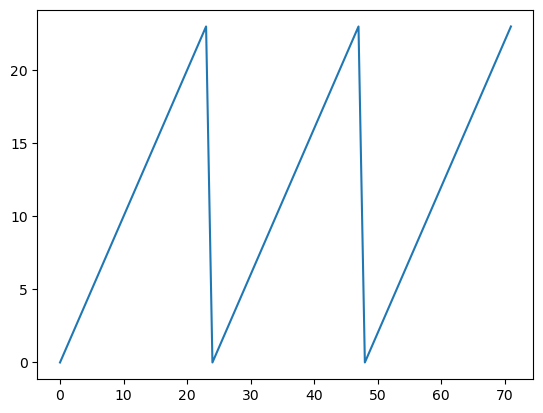

In [34]:
plt.plot(time_array.hour[:72]); plt.show()

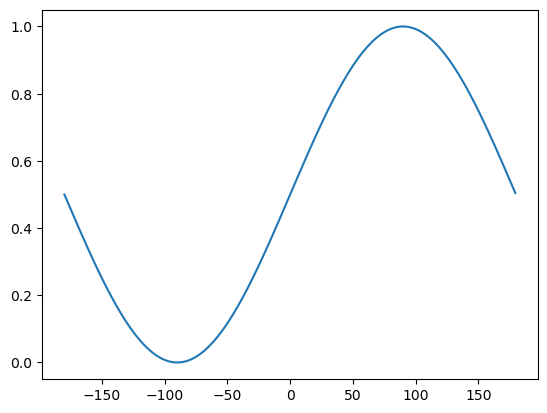

In [161]:
x_arr = np.arange(-180,180,0.5)
thatthing = (np.sin(x_arr/360*2*np.pi)+1)/2
plt.plot(x_arr, thatthing)
plt.show()

In [158]:
ything = np.arange(1,366,1)
thisthing=(np.sin(ything/365*2*np.pi)+1)/2

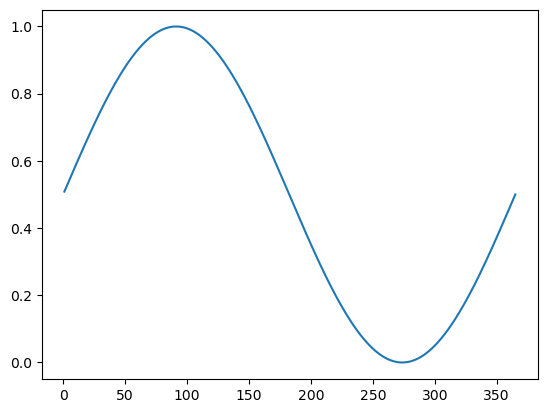

In [160]:
plt.plot(ything, thisthing)
plt.show()

In [59]:
scaled_doy = (time_array.dayofyear/365)*2*np.pi
sine_encoded_doy = np.sin(scaled_doy)  
cosine_encoded_doy = np.cos(scaled_doy)

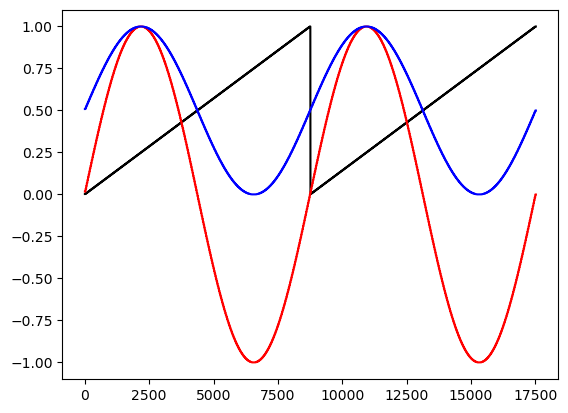

In [60]:
# normalization
plt.plot(time_array.dayofyear/365, c='k')
plt.plot(sine_encoded_doy, c='r')
plt.plot((sine_encoded_doy+1)/2, c='b') ## use this one!
plt.show()

In [37]:
scaled_hour = (time_array.hour/24)*2*np.pi
sine_encoded_hour = np.sin(scaled_hour)  
cosine_encoded_hour = np.cos(scaled_hour)

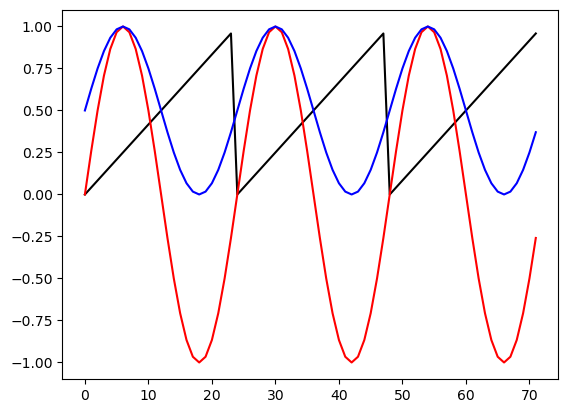

In [44]:
# normalization
plt.plot(time_array.hour[:72]/24, c='k')
plt.plot(sine_encoded_hour[:72], c='r')
plt.plot((sine_encoded_hour[:72]+1)/2, c='b'); 
plt.show()

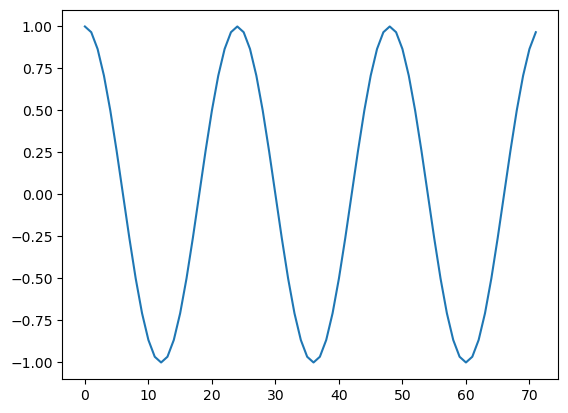

In [39]:
plt.plot(cosine_encoded_hour[:72]); plt.show()

In [11]:
var_cos.shape

(121,)

In [10]:
var_sin.shape

(121,)

In [ ]:
#var_sin = np.sin(ds_error.longitude.values * (2. * np.pi / np.max(ds_error.longitude.values)))
#var_cos = np.cos(ds_error.longitude.values * (2. * np.pi / np.max(ds_error.longitude.values)))